In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
plt.style.use('ggplot')
%matplotlib inline

### Пункты 1-2

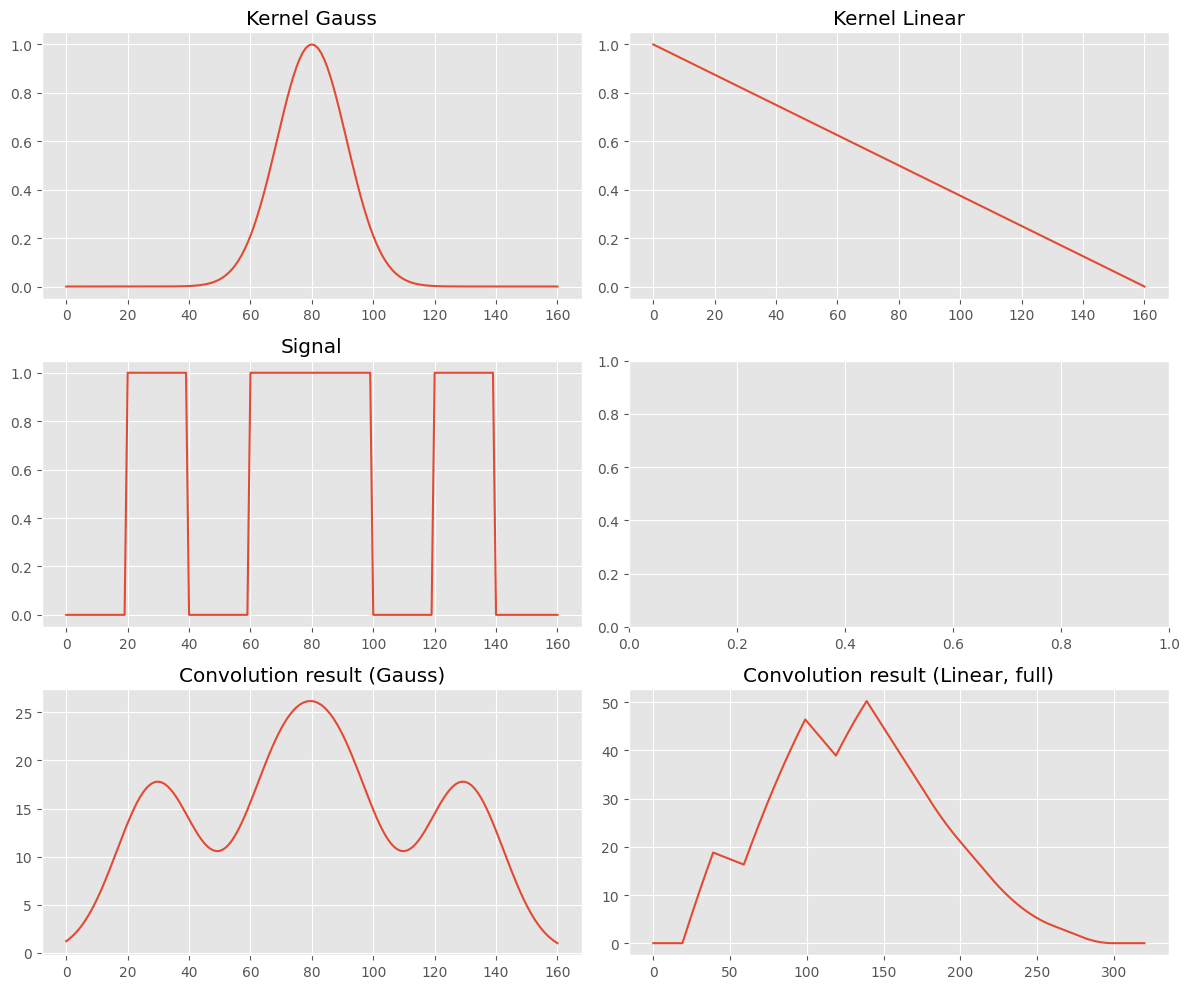

In [6]:
# Параметры
N = 161
t = np.arange(N)

# Прямоугольный периодический сигнал
signal = np.zeros(N)
signal[20:40] = 1
signal[60:100] = 1
signal[120:140] = 1

# Ядро Гаусс
x = np.linspace(-5, 5, N)
kernel_gauss = np.exp(-x**2)          # A=1

# Ядро линейное (падающее)
kernel_linear = np.linspace(1, 0, N)

conv_gauss_np = np.convolve(signal, kernel_gauss, mode='same')
conv_linear_np = np.convolve(signal, kernel_linear, mode='full')


def my_convolve(sig, kern):
    sig_pad = np.pad(sig, (len(kern)//2, len(kern)//2), mode='constant')
    result = np.zeros_like(sig)
    for i in range(len(sig)):
        result[i] = np.sum(sig_pad[i:i+len(kern)] * kern)
    return result

conv_gauss_my = my_convolve(signal, kernel_gauss)
conv_linear_my = my_convolve(signal, kernel_linear)

t_full = np.arange(len(conv_linear_np))          # 0..320


# Графики 
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs[0,0].plot(t, kernel_gauss); axs[0,0].set_title('Kernel Gauss')
axs[1,0].plot(t, signal); axs[0,1].set_title('Kernel Linear')
axs[0,1].plot(t, kernel_linear); axs[1,0].set_title('Signal')
axs[2,0].plot(t, conv_gauss_np); axs[2,0].set_title('Convolution result (Gauss)')
axs[2,1].plot(t, conv_linear_np); axs[2,1].set_title('Convolution result (Linear)')
# axs[2,1].plot(t_full, conv_linear_np)
# axs[2,1].set_title('Convolution result (Linear, full)')
plt.tight_layout()
plt.show()

### Пункт 3

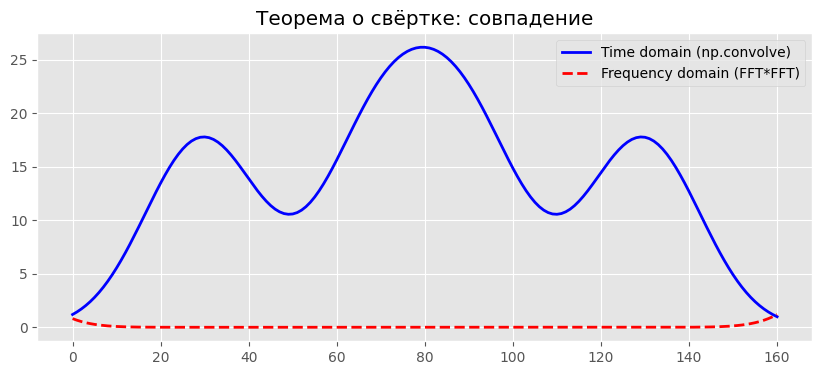

In [6]:
pad = N//2
sig_pad = np.pad(signal, (pad, pad), 'constant')
kern_pad = np.pad(kernel_gauss, (pad, pad), 'constant')

# FFT
S = fft(sig_pad)
K = fft(kern_pad)
conv_freq = ifft(S * K).real

# Обрезаем обратно к длине N
conv_freq = conv_freq[pad:pad+N]

# Сравниваем с временной свёрткой
plt.figure(figsize=(10, 4))
plt.plot(t, conv_gauss_np, 'b-', label='Time domain (np.convolve)', linewidth=2)
plt.plot(t, conv_freq[:N], 'r--', label='Frequency domain (FFT*FFT)', linewidth=2)
plt.title('Теорема о свёртке: совпадение')
plt.legend()
plt.show()

### Пункты 4-5

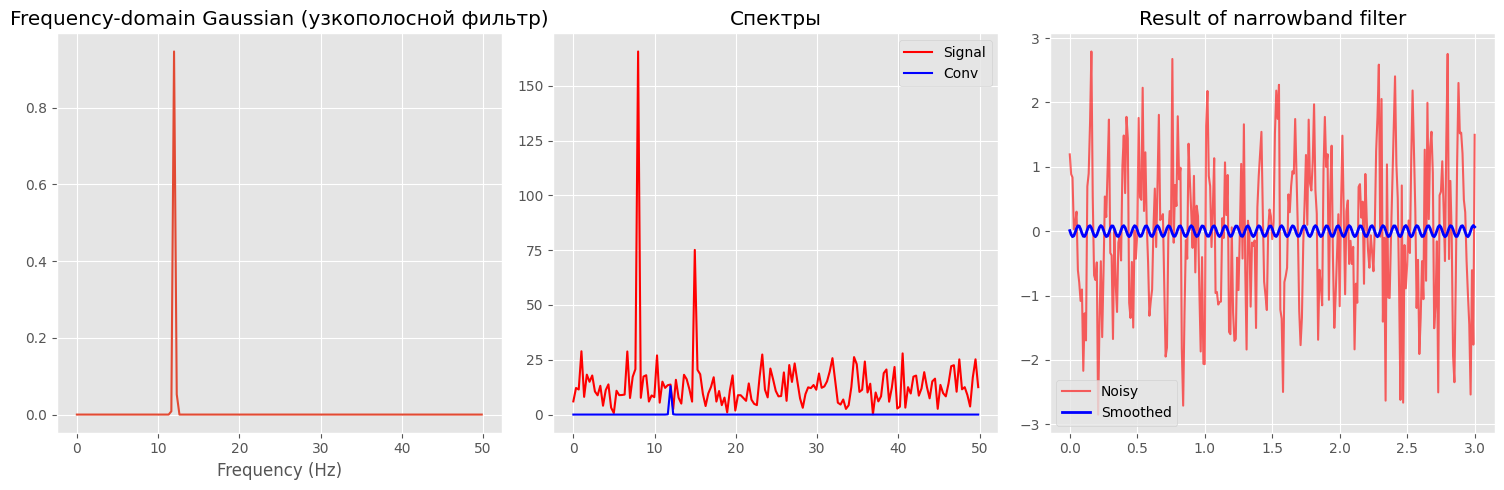

In [8]:
def to_full_freq_response(H_pos):
    """Превращает массив положительных частот (len = N//2 + 1)
       в полный Hermitian-symmetric массив длины N"""
    return np.concatenate((H_pos, H_pos[1:][::-1]))

# Общие параметры
fs = 100.0
T = 3.0
N = 301
t = np.linspace(0, T, N)
freq = fftfreq(N, 1/fs)[:N//2 + 1]   # положительные частоты (151 элементов)

# Зашумлённый сигнал
signal_clean = np.sin(2*np.pi*8*t) + 0.5*np.sin(2*np.pi*15*t)
noise = 0.8 * np.random.randn(N)
signal_noisy = signal_clean + noise

# === Параметры Гаусса в частотной области ===
p = 0.0          # центральная частота
w = 8.0          # FWHM (Hz)
s = w / (2*np.pi - 1) / (4*np.pi)
h = freq

# (а) Узкополосной фильтр — как требуется в лабораторной
p_narrow = 12.0
G_narrow = np.exp(-0.5 * ((h - p_narrow)/s)**2)

# (б) ФНЧ (можно включить для проверки, раскомментировать)
# G_lowpass = np.exp(-0.5 * ((h - p)/s)**2)

# Фильтрация (используем исправленную функцию!)
S_noisy = fft(signal_noisy)
S_filtered = S_noisy * to_full_freq_response(G_narrow)   # ← ИСПРАВЛЕНО
filtered_time = ifft(S_filtered).real

# Графики (как на Рис. 5)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(freq, G_narrow)
axs[0].set_title('Frequency-domain Gaussian (узкополосной фильтр)')
axs[0].set_xlabel('Frequency (Hz)')

axs[1].plot(freq, np.abs(S_noisy[:N//2+1]), 'r', label='Signal')
axs[1].plot(freq, np.abs(S_filtered[:N//2+1]), 'b', label='Conv')
axs[1].set_title('Спектры')
axs[1].legend()

axs[2].plot(t, signal_noisy, 'r', alpha=0.6, label='Noisy')
axs[2].plot(t, filtered_time, 'b', linewidth=2, label='Smoothed')
axs[2].set_title('Result of narrowband filter')
axs[2].legend()

plt.tight_layout()
plt.show()

### Пункт 6

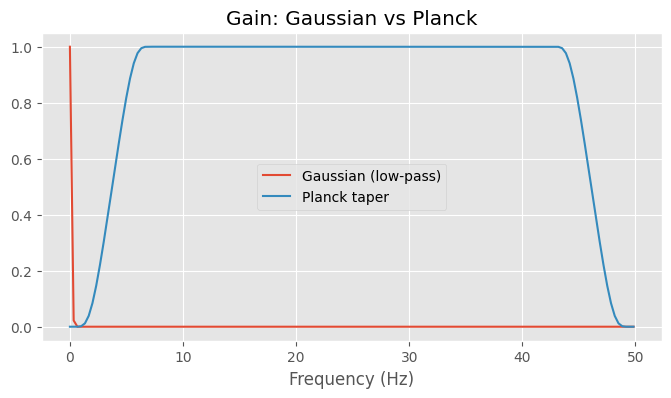

In [11]:
def planck_taper_window(M, epsilon=0.2):
    """Точная реализация окна Планка (как в лабораторной)"""
    a = np.zeros(M)
    if M <= 1 or not (0 < epsilon <= 0.5):
        return a
    eps_Nm1 = epsilon * (M - 1)
    for k in range(1, M-1):
        if k < eps_Nm1:
            za = eps_Nm1 * (1/k + 1/(k - eps_Nm1))
            a[k] = 1 / (np.exp(za) + 1)
        elif k <= (1 - epsilon) * (M - 1):
            a[k] = 1.0
        else:
            zb = eps_Nm1 * (1/(M-1-k) + 1/((1-epsilon)*(M-1) - k))
            a[k] = 1 / (np.exp(zb) + 1)
    return a

M = len(freq)
H_planck = planck_taper_window(M, epsilon=0.15)   # подберите epsilon под нужную ширину

# Фильтрация (исправлено!)
S_filtered_planck = S_noisy * to_full_freq_response(H_planck)  # ← ИСПРАВЛЕНО
filtered_planck = ifft(S_filtered_planck).real

plt.figure(figsize=(8, 4))
plt.plot(freq, G, label='Gaussian (low-pass)')
plt.plot(freq, H_planck, label='Planck taper')
plt.title('Gain: Gaussian vs Planck')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.show()

### Пункт 7

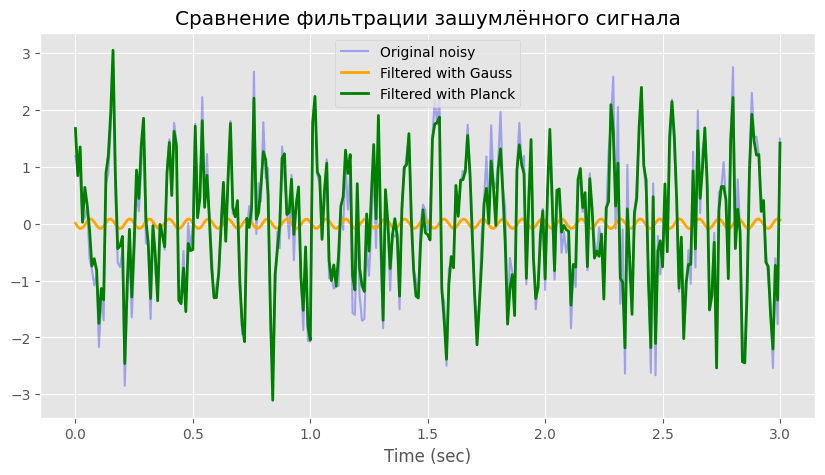

In [12]:
# Сравнение (как на Рис. 7 справа)
plt.figure(figsize=(10, 5))
plt.plot(t, signal_noisy, 'b-', alpha=0.3, label='Original noisy')
plt.plot(t, filtered_time, 'orange', linewidth=2, label='Filtered with Gauss')
plt.plot(t, filtered_planck, 'green', linewidth=2, label='Filtered with Planck')
plt.title('Сравнение фильтрации зашумлённого сигнала')
plt.xlabel('Time (sec)')
plt.legend()
plt.show()